In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [156]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
block_size = 3

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [36]:
# utility function to compare manual gradients to PyTorch gradients
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = abs(dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact:{str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [157]:
n_embd = 10
n_hidden = 64

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.1 # basically useless because of BatchNorm
# Layer 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.1
# BatchNorm params
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # nr of params in total
for p in parameters:
    p.requires_grad = True

4137


In [158]:
batch_size = 32
n = batch_size
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

In [159]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # cat the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h  @ W2 + b2 # output layer
# cross entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, counts, counts_sum, counts_sum_inv,
        norm_logits, logit_maxes, logits, h, hpreact, bnraw,
        bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
        embcat, emb, probs]:
    t.retain_grad()
loss.backward()
loss

tensor(3.4937, grad_fn=<NegBackward0>)

tensor(0., grad_fn=<MaxBackward1>)

In [123]:
# Exercise 1: backprob through the whole thing manually
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# The loss only looks at the logprobs of the correct indices, scales by -1, and divides by n
# All other elements have a gradient of 0.
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
# INVALID: dcounts_sum = (-1 * dcounts_sum_inv**-2) / n
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = ((-0.5 * (bnvar + 1e-5)**-1.5) * 1) * dbnvar_inv
dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar
dbndiff += (2 * bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0, keepdim=True)
dhprebn += 1.0/n * torch.ones_like(hprebn) * dbnmeani
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]


cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact:True  | approximate: True  | maxdiff: 0.0
probs           | exact:True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact:True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact:True  | approximate: True  | maxdiff: 0.0
counts          | exact:True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact:True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact:True  | approximate: True  | maxdiff: 0.0
logits          | exact:True  | approximate: True  | maxdiff: 0.0
h               | exact:True  | approximate: True  | maxdiff: 0.0
W2              | exact:True  | approximate: True  | maxdiff: 0.0
b2              | exact:True  | approximate: True  | maxdiff: 0.0
hpreact         | exact:True  | approximate: True  | maxdiff: 0.0
bngain          | exact:True  | approximate: True  | maxdiff: 0.0
bnbias          | exact:True  | approximate: True  | maxdiff: 0.0
bnraw           | exact:True  | approximate: True  | maxdiff: 0.0
bnvar_inv 

In [107]:
# loss = -(a + b + c) / 3
# dloss/da = -1/n

In [125]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete the challenge look at the mathematical expression of the loss
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes
# counts = norm_logits.exp()
# counts_sum = counts.sum(1. keepdims=True)
# counts_sum_inv = counts_sum**-1
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())


3.3581619262695312 diff: -2.384185791015625e-07


In [126]:
# backward pass

dlogits = F.softmax(logits, 1) # Do the softmax along the rows of the logits(dim 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact:False | approximate: True  | maxdiff: 6.51925802230835e-09


In [127]:
dlogits[0]

tensor([ 0.0020,  0.0027,  0.0007,  0.0016,  0.0007,  0.0026,  0.0008,  0.0010,
        -0.0307,  0.0010,  0.0011,  0.0012,  0.0013,  0.0009,  0.0011,  0.0005,
         0.0003,  0.0006,  0.0005,  0.0016,  0.0016,  0.0006,  0.0008,  0.0022,
         0.0019,  0.0008,  0.0007], grad_fn=<SelectBackward0>)

In [128]:
dlogits[0] * n

tensor([ 0.0631,  0.0858,  0.0220,  0.0497,  0.0212,  0.0830,  0.0259,  0.0331,
        -0.9821,  0.0326,  0.0354,  0.0369,  0.0420,  0.0277,  0.0351,  0.0152,
         0.0093,  0.0201,  0.0149,  0.0521,  0.0510,  0.0204,  0.0253,  0.0718,
         0.0599,  0.0259,  0.0224], grad_fn=<MulBackward0>)

In [137]:
dlogits[0].sum()

tensor(0., grad_fn=<SumBackward0>)

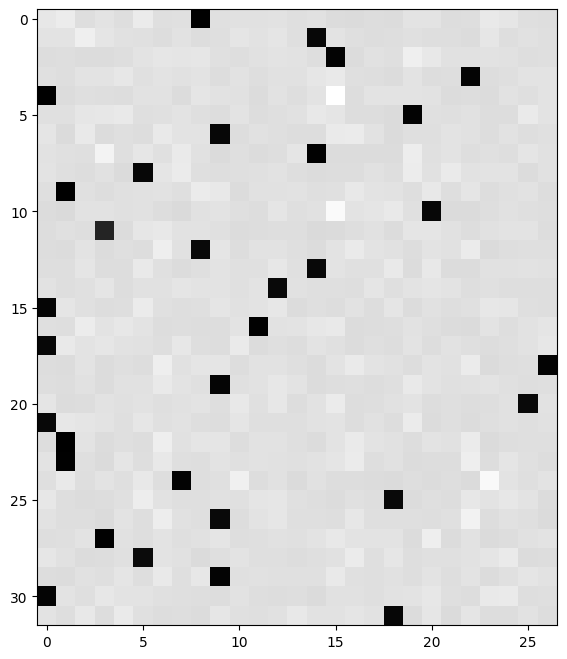

In [131]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray')

In [139]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge we will look at the mathematical expression of the output of batchnorm
# 1. take the derivative w.r.t its input, 2. simplify the expression, 3. write it out

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar 1/(n-1)*(bndiff2).sum(0, keepdim=True)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [ ]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (--> backprob through batchnorm)

dhprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n / (n-1) * bnraw * (dhpreact * bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # Basically 0

hprebn          | exact:False | approximate: True  | maxdiff: 9.313225746154785e-10


In [141]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [161]:
batch_size = 32
lossi = []

for i in range(30000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # cat the vectors
    # Linear layer
    hprebn = embcat @ W1 #+ b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hpreact - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias # from the Normalization via Mini-Batch Statistics paper --> Basically forces to follow Gaussian distribution
    # -------------------------------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    #loss.backward()
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

    dlogprobs = torch.zeros_like(logprobs)
    dlogprobs[range(n), Yb] = -1.0 / n
    dprobs = (1.0 / probs) * dlogprobs
    dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
    # INVALID: dcounts_sum = (-1 * dcounts_sum_inv**-2) / n
    dcounts = counts_sum_inv * dprobs
    dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
    dcounts += torch.ones_like(counts) * dcounts_sum
    dnorm_logits = counts * dcounts
    dlogits = dnorm_logits.clone()
    dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
    dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    dhpreact = (1.0 - h**2) * dh
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnraw = bngain * dhpreact
    dbnbias = dhpreact.sum(0, keepdim=True)
    dbndiff = bnvar_inv * dbnraw
    dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
    dbnvar = ((-0.5 * (bnvar + 1e-5)**-1.5) * 1) * dbnvar_inv
    dbndiff2 = (1.0 / (n-1)) * torch.ones_like(bndiff2) * dbnvar
    dbndiff += (2 * bndiff) * dbndiff2
    dhprebn = dbndiff.clone()
    dbnmeani = (-dbndiff).sum(0, keepdim=True)
    dhprebn += 1.0/n * torch.ones_like(hprebn) * dbnmeani
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k,j]
            dC[ix] += demb[k,j]
    
    # update
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
        #p.data += -lr * p.grad
        p.data += -lr * grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{20000}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/20000: 3.4374
  10000/20000: nan
  20000/20000: nan
